# Input

In [1]:
%reload_ext autoreload
%autoreload 2
%matplotlib inline
import warnings
import matplotlib
import matplotlib.pyplot as plt
import sys 
import os 
import pandas as pd
import anndata as ad
import scanpy as sc
import numpy as np
import seaborn as sns
from tqdm import tqdm
import subprocess
from sklearn.metrics import r2_score

import pandas as pd
from scipy.stats import linregress
import matplotlib.patches as mpatches
from scipy.stats import pearsonr, spearmanr
from pandas.api.types import CategoricalDtype
from scipy.cluster.hierarchy import linkage
from matplotlib.patches import Patch
from statsmodels.stats.multitest import multipletests

# pd.set_option('display.max_columns', None)
# pd.set_option('display.max_colwidth', None)
# np.set_printoptions(threshold=np.inf)

plt.rcParams["figure.figsize"]=4,4

warnings.filterwarnings("ignore")

# - dirs 
from ciim.src.common import plots_dir, base_dir, aging_clock_train_datasets, palette_genders, palette_treatment, \
        mapping_major_2_minor, mapping_minor_2_major, cell_types, datasets_e, datasets_all, datasets_a, palette_datasets, \
        datasets_disease, datasets_drug_perturbation, save_dir, \
        palette_datasets_pretty, surrogate_names, colors_blind, palette_trend, palette_trend_2, palette_regulation, palette_cell_types

from ciim.src.utils.util import  retrieve_adata, retrieve_net,  get_consensus_net
from ciim.src.feature_association.helper import retrieve_feature_data
from ciim.src.clock.helper import clock_save_dir, predict_age
from ciim.src.clock.plots import plot_scatter_age_vs_predictedAge

# - settings
feature_type = 'gene_expression' # 'tf_activity' gene_expression
data_type = 'bulk'
reg_type = 'ridge' 
tune_model = True
create_smoothed_data = True
only_targets = True
temp_dir = f'{save_dir}/temp/'
plt.rcParams["font.family"] = "Arial"
cell_types = ['CD4T', 'CD8T', 'MONO', 'B', 'NK'] # ['CD4T', 'CD8T', 'MONO', 'B', 'NK']
train_datasets = aging_clock_train_datasets
n_cell_types = len(cell_types)
version = 'all_data'

def get_all_predictions(cell_types, evaluate_datasets, version='all_data'):
    obs_store = []
    for cell_type in cell_types:
        for dataset in evaluate_datasets:
            adata = ad.read_h5ad(f"{save_dir}/{feature_type}_smoothed/{dataset}_{cell_type}_{data_type}.h5ad")
            adata.obs['condition'] = adata.obs['condition'].apply(lambda name: surrogate_names.get(name, name))
            conds = adata.obs['condition'].unique()
            for cond in conds:
                adata_c = adata[adata.obs['condition'] == cond]
                adata_c = predict_age(adata_c, cell_type, feature_type=feature_type, data_type=data_type, reg_type=reg_type, version=version)
                obs = adata_c.obs
                obs['dataset'] = dataset
                obs['cell_type'] = cell_type
                obs['condition'] = cond
                obs_store.append(obs)
    obs = pd.concat(obs_store, axis=0)
    return obs
print(train_datasets)

['data1', 'data7_allTPs_jalil']


# Calculate feature space using consensus GRNs -> smoothened

In [95]:
datasets = ['op'] + datasets_drug_perturbation + datasets_all + datasets_disease  #'parsebioscience' 'ibd',
# datasets = ['CXCL9']
if False:
    adata_integrated = ad.read_h5ad(f'{save_dir}/gene_expression_smoothed/adata_latent_corrected.h5ad')
    for dataset in datasets:
        for cell_type in cell_types:
            print(f'Preparing data for {dataset} {cell_type} {feature_type}')
            adata = adata_integrated[(adata_integrated.obs['dataset'] == dataset)&(adata_integrated.obs['cell_type'] == cell_type)].copy()
            adata.write(f'{save_dir}/{feature_type}_smoothed/{dataset}_{cell_type}_{data_type}.h5ad')
if create_smoothed_data:
    from ciim.src.clock.helper import format_data
    for dataset in datasets:
        for cell_type in cell_types:
            print(f'Preparing data for {dataset} {cell_type} {feature_type}')
            adata_s = format_data([dataset], cell_type=cell_type, data_type=data_type, only_ctr=False, only_targets=only_targets)
            # adata_s = adata[(adata.obs['dataset'] == dataset)&(adata.obs['cell_type'] == cell_type)].copy()
            obs = adata_s.obs.dropna(axis=1, how='all')
            adata_s.obs = obs
            for col in adata_s.obs.columns:
                if adata_s.obs[col].dtype == "object":
                    adata_s.obs[col] = adata_s.obs[col].astype(str)

            adata_s.write(f'{save_dir}/{feature_type}_smoothed/{dataset}_{cell_type}_{data_type}.h5ad')

Preparing data for CXCL9 CD4T gene_expression
Datasets in merged adata: ['CXCL9']
Cell types in merged adata: ['CD4T']
Categories (1, object): ['CD4T']
Preparing data for CXCL9 CD8T gene_expression
Datasets in merged adata: ['CXCL9']
Cell types in merged adata: ['CD8T']
Categories (1, object): ['CD8T']
Preparing data for CXCL9 MONO gene_expression
Datasets in merged adata: ['CXCL9']
Cell types in merged adata: ['MONO']
Categories (1, object): ['MONO']
Preparing data for CXCL9 B gene_expression
Datasets in merged adata: ['CXCL9']
Cell types in merged adata: ['B']
Categories (1, object): ['B']
Preparing data for CXCL9 NK gene_expression
Datasets in merged adata: ['CXCL9']
Cell types in merged adata: ['NK']
Categories (1, object): ['NK']


In [19]:
retrieve_adata(dataset='CXCL9', type='sc')

AnnData object with n_obs × n_vars = 90315 × 19605
    obs: 'dataset', 'donor_id', 'age', 'sex', 'batch_info', 'pool_id', 'donor_letter', 'treatment_id', 'condition', 'donor_age', 'n_genes_by_counts', 'total_counts', 'total_counts_mt', 'pct_counts_mt', 'n_genes', 'Major_CT', 'Sub_CT', 'cell_type', 'is_control'
    var: 'gene_symbols', 'mt', 'n_cells_by_counts', 'mean_counts', 'pct_dropout_by_counts', 'total_counts', 'n_cells', 'n_counts'
    uns: 'log1p'

# Feature analysis

In [2]:
features_dict = {}
for cell_type in cell_types:
    adata = ad.read_h5ad(f'{save_dir}/{feature_type}_smoothed/data1_{cell_type}_{data_type}.h5ad')
    # min_degree = min(len(aging_clock_train_datasets), 4)
    # net = get_consensus_net(datasets_all, cell_type)
    features_dict[cell_type] = adata.var_names.tolist() # net[net['degree']>=min_degree]['feature'].tolist()

## Intersection of features

In [3]:
from task_grn_inference.src.exp_analysis.helper import plot_interactions, create_interaction_df

interaction_main_df = create_interaction_df(features_dict)

['MONO', 'CD8T', 'B', 'CD4T', 'NK']


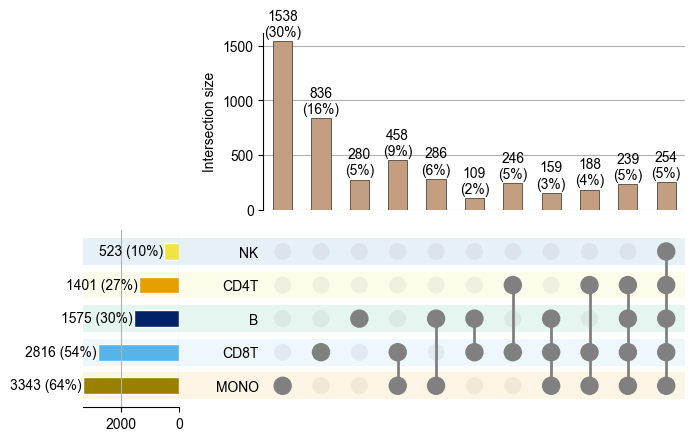

In [131]:
aa = plot_interactions(interaction_main_df, min_subset_size=100, min_degree=1, color_map=palette_cell_types)

plt.savefig(f'{plots_dir}/interactions_targets.png', dpi=300, transparent=True, bbox_inches='tight')
# plt.title(surrogate_names[race], pad=40, fontsize=10, fontweight='bold')

## Pathway analysis

In [4]:
import gseapy as gp
from gseapy import barplot, dotplot
all_genes = np.loadtxt(f'{base_dir}/prior/gene_names.txt', dtype=str)
print(all_genes)
gene_sets = 'MSigDB_Hallmark_2020'
res2d_store = []
for cell_type, genes in features_dict.items():
    rr = gp.enrichr(gene_list=list(genes),
                gene_sets=gene_sets, #, 'KEGG_2021_Human'
                organism='human', 
                outdir=None, 
                cutoff=1,
                # background=list(all_genes),
                )
    res2d = rr.res2d
    res2d.rename(columns={'Adjusted P-value': 'FDR'}, inplace=True)
    filter_col = 'FDR' #'FDR q-val'
    res2d = res2d[res2d[filter_col]<0.05]
    if res2d.shape[0] == 0:
        continue
    print(res2d.shape)
    res2d['cell_type'] = cell_type
    res2d_store.append(res2d)

pathway_scores = pd.concat(res2d_store)

pathway_scores['n_genes'] = pathway_scores['Genes'].str.split(';').apply(len)
pathway_scores["neg_log10_adj_pval"] = -np.log10(pathway_scores["FDR"])

['DDX11L16' 'DDX11L1' 'WASH7P' ... 'ENSG00000149656' 'ENSG00000310230'
 'IQSEC3P3']
(34, 10)
(34, 10)
(33, 10)
(34, 10)
(26, 10)


In [7]:
pathway_scores[pathway_scores['cell_type']=='CD4T']['Term'].unique()

array(['Interferon Gamma Response', 'TNF-alpha Signaling via NF-kB',
       'Interferon Alpha Response', 'IL-2/STAT5 Signaling',
       'Allograft Rejection', 'Apoptosis', 'Myc Targets V1', 'Hypoxia',
       'p53 Pathway', 'Inflammatory Response', 'mTORC1 Signaling',
       'IL-6/JAK/STAT3 Signaling', 'Complement', 'Androgen Response',
       'UV Response Dn', 'PI3K/AKT/mTOR  Signaling', 'KRAS Signaling Up',
       'UV Response Up', 'Estrogen Response Early',
       'Unfolded Protein Response', 'TGF-beta Signaling',
       'heme Metabolism', 'Mitotic Spindle', 'Adipogenesis',
       'Reactive Oxygen Species Pathway', 'Estrogen Response Late',
       'Apical Junction', 'Cholesterol Homeostasis', 'Protein Secretion',
       'G2-M Checkpoint', 'E2F Targets',
       'Epithelial Mesenchymal Transition', 'Oxidative Phosphorylation',
       'Glycolysis'], dtype=object)

In [8]:
pathway_scores[pathway_scores['cell_type']=='CD4T'].head()

,Gene_set,Term,Overlap,P-value,FDR,Old P-value,Old Adjusted P-value,Odds Ratio,Combined Score,Genes,cell_type,n_genes,neg_log10_adj_pval
0,MSigDB_Hallmark_2020,Interferon Gamma Response,89/200,1.822964e-49,8.932525e-48,0,0,11.298561,1267.994604,CDKN1A;SAMD9L;IFITM2;BTG1;EIF4E3;TNFAIP3;UBE2L...,CD4T,89,47.049026
1,MSigDB_Hallmark_2020,TNF-alpha Signaling via NF-kB,80/200,2.394236e-40,5.865879e-39,0,0,9.325763,850.792552,BTG2;CDKN1A;BTG1;CD83;B4GALT1;PLEK;TNFAIP3;IRS...,CD4T,80,38.231667
2,MSigDB_Hallmark_2020,Interferon Alpha Response,51/97,2.639540e-33,4.311249e-32,0,0,15.236763,1142.981278,IFITM1;SAMD9L;IFITM2;UBE2L6;ADAR;IFI35;IFIT3;I...,CD4T,51,31.365397
3,MSigDB_Hallmark_2020,IL-2/STAT5 Signaling,68/199,1.600975e-29,1.961195e-28,0,0,7.191630,476.836383,PHTF2;CD83;GPR65;RORA;SLC2A3;AHR;IKZF2;IKZF4;I...,CD4T,68,27.707479
4,MSigDB_Hallmark_2020,Allograft Rejection,65/200,7.581400e-27,7.429772e-26,0,0,6.654247,400.213699,ITK;GPR65;PRF1;ITGAL;RPL9;CD3D;TNF;ETS1;CCND3;...,CD4T,65,25.129025


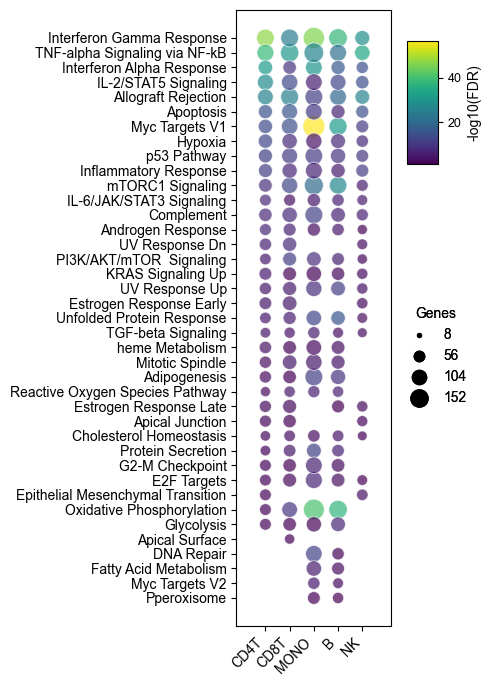

In [12]:
from ciim.src.feature_association.plots import dotplot_category_color
from ciim.src.common import surrogate_names
    
fig, ax = plt.subplots(1, 1, figsize=(2, 8), sharey=True, sharex=True)

pathway_scores['cell_type'] = pd.Categorical(pathway_scores['cell_type'], categories=cell_types, ordered=True)
show_color_legend = True
show_size_legend = True

dotplot_category_color(pathway_scores, 
            ax, 
            color_col='neg_log10_adj_pval', 
            size_col='n_genes', 
            x='cell_type', 
            y='Term', 
            palette='viridis', 
            sizes=(50, 250),
            show_color_legend=show_color_legend, 
            show_size_legend=show_size_legend,
            size_legend_title='Genes',
            color_legend_title='-log10(FDR)',
            color_legend_loc=(1.1, 0.75),
            size_legend_loc=(1.05, 0.35),
            size_legend_scale=1,
            y_label='',
            alpha=0.7)
plt.savefig(f'{plots_dir}/enrichment_targets.png', dpi=300, transparent=True, bbox_inches='tight')

## Time trend of selected genes

In [102]:
from ciim.src.clock.helper import retrieve_function
top_genes_dict = {}
top_weights_dict = {}
for cell_type in cell_types:
    model, gene_names = retrieve_function(reg_type, cell_type, data_type, feature_type, version)
    coefs = model.named_steps["ridge"].coef_
    abs_coefs = np.abs(coefs)
    top_idx = np.argsort(abs_coefs)[-5:][::-1]
    top_genes = [gene_names[i] for i in top_idx]
    top_genes_dict[cell_type] = top_genes
    top_weights_dict[cell_type] = coefs[top_idx]

In [103]:
top_genes_dict

{'CD4T': ['TSHZ2', 'C1orf162', 'LRRN3', 'AUTS2', 'IGFBP3'],
 'CD8T': ['LRRN3', 'CDKN2A', 'COTL1', 'CD70', 'GPR171'],
 'MONO': ['VAMP5', 'CRIP1', 'S100A10', 'TMSB10', 'ANXA1'],
 'B': ['PPP1R14A', 'ARL4C', 'ITGB1', 'YBX3', 'FXYD1'],
 'NK': ['PTGDS', 'CLIC3', 'CCL5', 'SSBP2', 'TYROBP']}

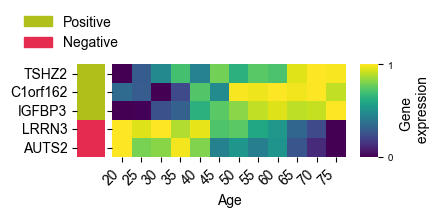

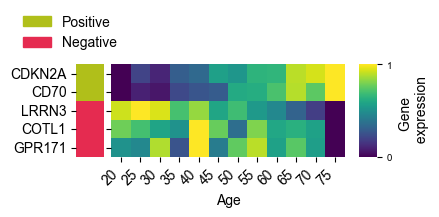

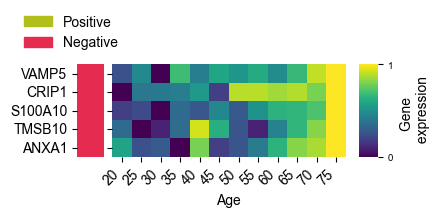

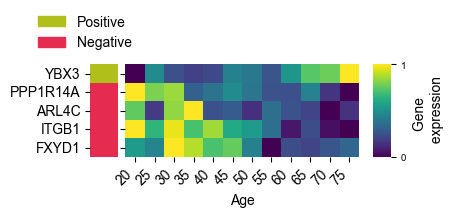

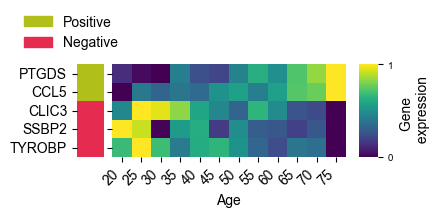

In [104]:
def plot_feature_values(cell_type, features, feature_type, dataset='data1', ax=None, show_cbar=True, type='bulk', 
                                    age_limit=[20, 80], show_ylabels=True):
    from ciim.src.feature_association.helper import retrieve_feature_data, bin_feature_values
    from ciim.src.feature_association.plots import heatplot_age_trend
       
    adata = retrieve_feature_data(dataset=dataset, cell_type=cell_type, type=type, feature_type=feature_type) 
    adata = adata[(adata.obs['age'] > age_limit[0]) & (adata.obs['age'] < age_limit[1])]
    adata = adata[:, adata.var_names.isin(features)]
    assert adata.shape[1]>0, f"Features {features} not found in dataset {dataset} for cell type {cell_type}"

    mean_expr = bin_feature_values(adata)
    # sort the index base on features
    mean_expr = mean_expr.loc[features]
    ages = sorted(mean_expr.columns)
    if ax is None:
        fig, ax = plt.subplots(figsize=(3, 2))

    heatplot_age_trend(mean_expr[ages], cmap='magma' if feature_type=='tf_activity' else 'viridis', 
                        cbar_title = "Gene \n expression" if feature_type == 'gene_expression' else (
                                    "TF \n activity" if feature_type == 'tf_activity' else "Gene score"
                                ),
                        ax=ax, 
                        show_cbar=show_cbar,
                        cbar_kws={
                            "shrink": 1,
                            "aspect": 5,       # Lower values = thicker colorbar (default is ~20)
                            "fraction": 0.1    # Controls the width space the cbar takes in the figure
                        })
    if not show_ylabels:
        ax.set_yticklabels([])
    ax.set_ylabel('')
    ax.set_xlabel('Age')
from matplotlib.colors import ListedColormap

for cell_type, features in top_genes_dict.items():
    fig, axes = plt.subplots(1, 2, figsize=(4, 1.2), width_ratios=[.1, 1], gridspec_kw={'wspace':0.05})
    # --- Left: weight sign heatmap ---
    ax = axes[0]
    top_weights = np.sign(top_weights_dict[cell_type])  # ±1
    df = pd.DataFrame({'feature': features, 'weight': top_weights})
    df = df.set_index('feature').loc[features]  # enforce order
    # sort df based on sign
    df = df.sort_values(by='weight', ascending=False)
    features = df.index.tolist()
    cmap = ListedColormap(['#E52B50', '#B0BF1A'])
    sns.heatmap(
        df[['weight']],
        cmap=cmap,
        cbar=False,
        ax=ax,
        annot=False )
    ax.set_xlabel("")
    red_patch = mpatches.Patch(color='#E52B50', label='Negative')
    green_patch = mpatches.Patch(color='#B0BF1A', label='Positive')
    ax.legend(handles=[green_patch, red_patch], bbox_to_anchor=(1.7, 1.6), loc='upper right', borderaxespad=0., frameon=False)
    ax.set_ylabel('')
    ax.set_xlabel('')
    ax.set_xticks([])

    ax = axes[1]
    plot_feature_values(cell_type, features, feature_type='gene_expression', dataset='data1', ax=ax, show_cbar=True, type='bulk', 
                                    age_limit=[20, 80], show_ylabels=True)
    ax.set_yticklabels([])
    # plt.title(f'{cell_type}', pad=15, weight='bold')
    plt.savefig(f'{plots_dir}/top_genes_{cell_type}.png', dpi=300, transparent=True, bbox_inches='tight')

# Train the model

In [12]:
if True:
    import subprocess
    cmd = [
        "python", "../src/clock/script.py",
        "--cell_types", *cell_types,
        "--datasets_training", *train_datasets, # train_datasets,
        "--feature_type", feature_type,
        "--data_type", data_type,
        "--reg_type", reg_type,
        "--version", version,
        "--temp_dir", temp_dir,
        "--age_limit", "20"

    ]
    if tune_model:
        cmd += ["--tune_model"]
    print("Running:", " ".join(cmd))
    subprocess.run(cmd, check=True)

Running: python ../src/clock/script.py --cell_types CD4T CD8T MONO B NK --datasets_training data1 data7_allTPs_jalil --feature_type gene_expression --data_type bulk --reg_type ridge --version all_data --temp_dir /vol/projects/jnourisa//output//temp/ --age_limit 20 --tune_model


{'cell_types': ['CD4T', 'CD8T', 'MONO', 'B', 'NK'], 'datasets_training': ['data1', 'data7_allTPs_jalil'], 'feature_type': 'gene_expression', 'data_type': 'bulk', 'reg_type': 'ridge', 'tune_model': True, 'version': 'all_data', 'temp_dir': '/vol/projects/jnourisa//output//temp/', 'age_limit': 20}
building model for cell type: CD4T
dataset
data1                 976
data7_allTPs_jalil    313
Name: count, dtype: int64


Best trial: 28. Best value: 0.721884: 100%|██████████| 30/30 [00:10<00:00,  2.91it/s]



 Best alpha: 999.8256, Best CV performance: 0.7219
building model for cell type: CD8T
dataset
data1                 976
data7_allTPs_jalil    313
Name: count, dtype: int64


Best trial: 22. Best value: 0.542016: 100%|██████████| 30/30 [00:10<00:00,  2.76it/s]


...


 Best alpha: 382.7582, Best CV performance: -2.4606
building model for cell type: B
dataset
data1                 975
data7_allTPs_jalil    312
Name: count, dtype: int64


Best trial: 27. Best value: -5.25589: 100%|██████████| 30/30 [00:10<00:00,  2.77it/s]



 Best alpha: 963.6768, Best CV performance: -5.2559
building model for cell type: NK
dataset
data1                 975
data7_allTPs_jalil    313
Name: count, dtype: int64


Best trial: 29. Best value: 0.167783: 100%|██████████| 30/30 [00:09<00:00,  3.31it/s]



 Best alpha: 212.2225, Best CV performance: 0.1678


# Cross-validation performance

In [106]:
def get_all_predictions(cell_types, evaluate_datasets, version='all_data'):
    obs_store = []
    for cell_type in cell_types:
        for dataset in evaluate_datasets:
            adata = ad.read_h5ad(f"{save_dir}/{feature_type}_smoothed/{dataset}_{cell_type}_{data_type}.h5ad")
            adata.obs['condition'] = adata.obs['condition'].apply(lambda name: surrogate_names.get(name, name))
            conds = adata.obs['condition'].unique()
            for cond in conds:
                adata_c = adata[adata.obs['condition'] == cond]
                adata_c = predict_age(adata_c, cell_type, feature_type=feature_type, data_type=data_type, reg_type=reg_type, version=version)
                obs = adata_c.obs
                obs['dataset'] = dataset
                obs['cell_type'] = cell_type
                obs['condition'] = cond
                obs_store.append(obs)
    obs = pd.concat(obs_store, axis=0)
    return obs
from ciim.src.common import test_datasets
obs = get_all_predictions(cell_types, test_datasets)

In [107]:
import pandas as pd
from scipy.stats import spearmanr
from sklearn.metrics import r2_score

# obs: DataFrame with at least ['cell_type','dataset','age','predicted_age']

fold_scores = {}
all_preds = []

for (cell_type_name, dataset_name), df in obs.groupby(['cell_type', 'dataset']):
    y_true = df['age'].values
    y_pred = df['predicted_age'].values

    # Compute metrics
    spearman_corr = spearmanr(y_true, y_pred).correlation
    r2 = r2_score(y_true, y_pred)

    # Store scores using a tuple as key
    fold_scores[(cell_type_name, dataset_name)] = {
        'spearman': round(spearman_corr, 3),
        'r2': round(r2, 3)
    }

    # Keep predictions with cell_type and dataset columns
    pred_df = df.copy()
    all_preds.append(pred_df)

# Convert scores dict to DataFrame
scores_df = pd.DataFrame.from_dict(fold_scores, orient='index')
scores_df.index = pd.MultiIndex.from_tuples(scores_df.index, names=['cell_type', 'dataset'])

# Concatenate predictions
predictions_df = pd.concat(all_preds)


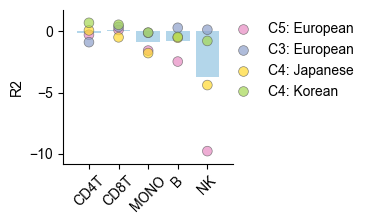

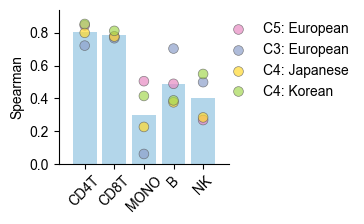

In [108]:
scores_df = scores_df.reset_index()  # make cell_type and dataset columns

# Optionally map dataset names to prettier versions
if 'surrogate_names' in globals():
    scores_df['dataset'] = scores_df['dataset'].map(lambda name: surrogate_names.get(name, name))

def plot_scores(cv_scores, metric, figsize=[2.5, 2]):
    fig, ax = plt.subplots(1, 1, figsize=figsize)

    # Strip plot (scatter of individual dataset scores)
    sns.stripplot(
        data=cv_scores, x='cell_type', y=metric,
        hue='dataset', dodge=False, jitter=False, s=7,
        alpha=0.7, linewidth=0.5, edgecolor='gray', palette=palette_datasets_pretty,
        ax=ax
    )

    # Bar plot (mean scores per cell type)
    sns.barplot(
        data=cv_scores, x='cell_type', y=metric,
        estimator='mean', errorbar=None,
        color=colors_blind[1], alpha=0.5, ax=ax
    )

    ax.set_xticklabels(ax.get_xticklabels(), rotation=45)
    ax.margins(x=0.1, y=0.1)
    ax.spines[['top', 'right']].set_visible(False)
    # Legend
    ax.legend(title='', bbox_to_anchor=(.9, 1), loc='upper left', frameon=False)
    ax.set(
        ylabel=metric.capitalize(),
        xlabel=''
    )
    return fig

# Plot R²
scores_df['cell_type'] = pd.Categorical(scores_df['cell_type'], categories=cell_types, ordered=True)
fig = plot_scores(scores_df, 'r2', figsize=(2.2, 2))
fig.savefig(f'{plots_dir}/{data_type}_{feature_type}_{reg_type}_celltype_dataset_r2.png',
            bbox_inches='tight', dpi=300, transparent=True)

# Plot Spearman
fig = plot_scores(scores_df, 'spearman', figsize=(2.2, 2))
fig.savefig(f'{plots_dir}/{data_type}_{feature_type}_{reg_type}_celltype_dataset_spearman.png',
            bbox_inches='tight', dpi=300, transparent=True)

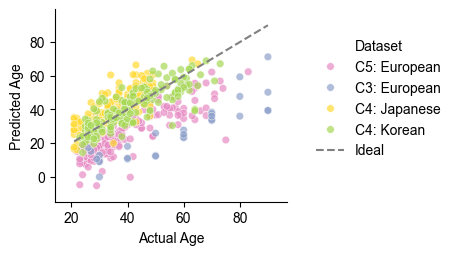

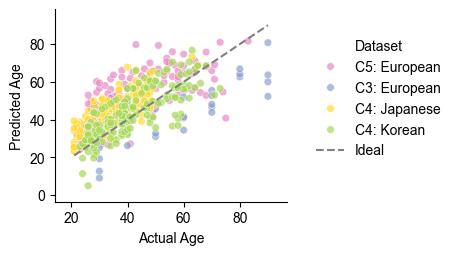

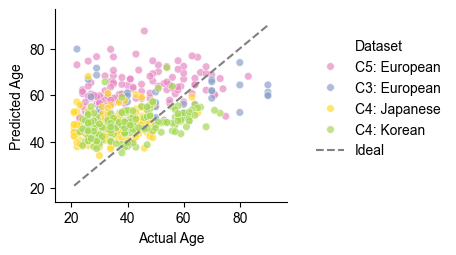

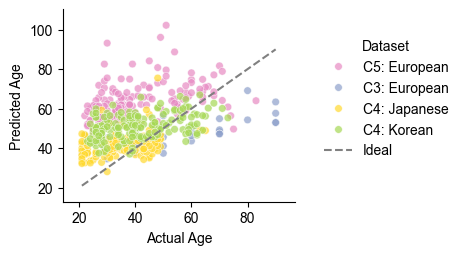

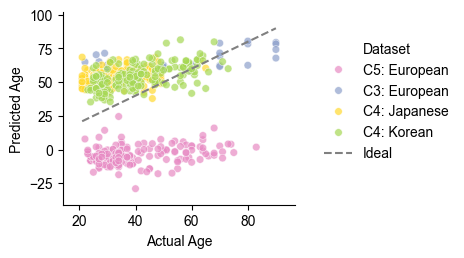

In [109]:
predictions_df['dataset'] = predictions_df['dataset'].apply(lambda name: surrogate_names.get(name, name))

for cell_type in cell_types:
    fig, ax = plt.subplots(1, 1, figsize=(3, 2.5), sharey=True)

    df = predictions_df[predictions_df['cell_type'] == cell_type]

    plot_scatter_age_vs_predictedAge(df, dataset='', ax=ax, hue='dataset', palette=palette_datasets_pretty, s=30, alpha=0.7)
    ax.legend(loc=(1.1, .2), frameon=False, title='Dataset')
    plt.savefig(f'{plots_dir}/clock_training_datasets.png', bbox_inches='tight', dpi=300, transparent=True)

#  Compare to wenchao's results

In [110]:
W_train_datasets = ['data1', 'data7_allTPs_jalil'] # we only use these datasets for training for a fair comparision
test_datasets = ['SLE_European', 'data13_Korean']

version = 'comparitive'

In [111]:
if True:
    import subprocess

    cmd = [
        "python", "../src/clock/script.py",
        "--cell_types", *cell_types,
        "--datasets_training", *W_train_datasets,
        "--feature_type", feature_type,
        "--data_type", data_type,
        "--reg_type", reg_type,
        "--version", version,
        "--temp_dir", temp_dir,
        "--age_limit", "20"

    ]
    if tune_model:
        cmd += ["--tune_model"]
    print("Running:", " ".join(cmd))
    subprocess.run(cmd, check=True)

Running: python ../src/clock/script.py --cell_types CD4T CD8T MONO B NK --datasets_training data1 data7_allTPs_jalil --feature_type gene_expression --data_type bulk --reg_type ridge --version comparitive --temp_dir /vol/projects/jnourisa//output//temp/ --age_limit 20 --tune_model


{'cell_types': ['CD4T', 'CD8T', 'MONO', 'B', 'NK'], 'datasets_training': ['data1', 'data7_allTPs_jalil'], 'feature_type': 'gene_expression', 'data_type': 'bulk', 'reg_type': 'ridge', 'tune_model': True, 'version': 'comparitive', 'temp_dir': '/vol/projects/jnourisa//output//temp/', 'age_limit': 20}
building model for cell type: CD4T
dataset
data1                 976
data7_allTPs_jalil    313
Name: count, dtype: int64


Best trial: 13. Best value: 0.721557: 100%|██████████| 30/30 [00:10<00:00,  2.75it/s]



 Best alpha: 979.1380, Best CV performance: 0.7216
building model for cell type: CD8T
dataset
data1                 976
data7_allTPs_jalil    313
Name: count, dtype: int64


Best trial: 16. Best value: 0.542046:  97%|█████████▋| 29/30 [00:13<00:00,  1.74it/s]

...

Best trial: 22. Best value: -3.42037: 100%|██████████| 30/30 [00:11<00:00,  2.51it/s]


building model for cell type: NK
dataset
data1                 975
data7_allTPs_jalil    313
Name: count, dtype: int64


Best trial: 11. Best value: 0.112314:  93%|█████████▎| 28/30 [00:02<00:00, 11.29it/s] 


 Best alpha: 962.9417, Best CV performance: 0.1123


Best trial: 11. Best value: 0.112314: 100%|██████████| 30/30 [00:02<00:00, 11.14it/s]


## Get W results on test data

In [112]:
def extract_w_results():
    # - read the results of predictions
    df_store = []
    for dataset in ['C4', 'C5']:
        df = pd.read_csv(f'{save_dir}/wenchao/val_data_majorCT_Wenchao_AC_{dataset}_predicted_age_donor.tsv', sep='\t')
        df['dataset'] = 'data13_Korean' if dataset=='C4' else 'SLE_European'
        df_store.append(df)
    df = pd.concat(df_store, axis=0)
    df['donor_age'] = df['donor_id'].astype(str) + '_' + df['age'].astype(str)
    # - format 
    df.rename(columns={'Prediction': 'predicted_age', 'CT': 'cell_type'}, inplace=True)
    df['sex'] = df['sex'].map({'M': 'Male', 'F': 'Female'})
    # - median prediction
    median_prediction = df.groupby(['cell_type', 'donor_age', 'dataset'])['predicted_age'].median().reset_index()
    median_prediction = df[['cell_type', 'donor_age', 'age', 'sex', 'dataset']].drop_duplicates().merge(median_prediction, on=['cell_type', 'donor_age', 'dataset'], how='left')
    return median_prediction
W_median_prediction = extract_w_results()

## Get our results on test data

In [113]:
predictions_all = get_all_predictions(cell_types, test_datasets, version=version)
predictions_all.head()

,sum_by,sex,cell_type,condition,dataset,Major_CT,donor_age,age,donor_id,orig.ident,race,cell_count,is_control,predicted_age,batch_info
148,_CD4T_1004_39.0,Female,CD4T,SLE,SLE_European,CD4T,100439,39,1004,SLE,European,1469,False,38.704475,NaN
149,_CD4T_1014_40.0,Female,CD4T,SLE,SLE_European,CD4T,101440,40,1014,SLE,European,988,False,30.626354,NaN
150,_CD4T_1015_54.0,Female,CD4T,SLE,SLE_European,CD4T,101554,54,1015,SLE,European,971,False,40.526501,NaN
151,_CD4T_1019_64.0,Female,CD4T,SLE,SLE_European,CD4T,101964,64,1019,SLE,European,2014,False,52.601940,NaN
152,_CD4T_1039_42.0,Female,CD4T,SLE,SLE_European,CD4T,103942,42,1039,SLE,European,840,False,11.861173,NaN


In [114]:
from ciim.src.clock.helper import evaluate_groupwise_median
test_predictions = predictions_all[(predictions_all['dataset'].isin(test_datasets)) & (predictions_all['condition']=='Healthy')]
test_predictions.head()

,sum_by,sex,cell_type,condition,dataset,Major_CT,donor_age,age,donor_id,orig.ident,race,cell_count,is_control,predicted_age,batch_info
224,_CD4T_HC-002_27.0,Male,CD4T,Healthy,SLE_European,CD4T,HC-00227,27,HC-002,SLE,European,1532,True,18.871404,NaN
225,_CD4T_HC-006_53.0,Female,CD4T,Healthy,SLE_European,CD4T,HC-00653,53,HC-006,SLE,European,2134,True,38.042705,NaN
226,_CD4T_HC-008_48.0,Female,CD4T,Healthy,SLE_European,CD4T,HC-00848,48,HC-008,SLE,European,792,True,35.731392,NaN
227,_CD4T_HC-009_27.0,Female,CD4T,Healthy,SLE_European,CD4T,HC-00927,27,HC-009,SLE,European,5346,True,12.260775,NaN
228,_CD4T_HC-020_35.0,Female,CD4T,Healthy,SLE_European,CD4T,HC-02035,35,HC-020,SLE,European,1155,True,23.919976,NaN


In [115]:
test_predictions['dataset'].unique()

array(['SLE_European', 'data13_Korean'], dtype=object)

## Calculate the scores

In [116]:
import pandas as pd

all_scores = []

for cell_type in test_predictions['cell_type'].unique():
    for dataset in test_datasets:
        # Your model
        df1 = test_predictions[
            (test_predictions['dataset'] == dataset) & 
            (test_predictions['cell_type'] == cell_type)
        ].copy()
        ss1 = evaluate_groupwise_median(df1)  # returns {'Spearman': ..., 'R2': ...}
        all_scores.append({
            'dataset': dataset,
            'cell_type': cell_type,
            'model': 'GRNdrived',
            'Spearman': ss1['Spearman'],
            'R2': ss1['R2']
        })

        # Wenchao's model
        df2 = W_median_prediction[
            (W_median_prediction['dataset'] == dataset) & 
            (W_median_prediction['cell_type'] == cell_type)
        ].copy()
        ss2 = evaluate_groupwise_median(df2)
        all_scores.append({
            'dataset': dataset,
            'cell_type': cell_type,
            'model': 'Wenchao',
            'Spearman': ss2['Spearman'],
            'R2': ss2['R2']
        })

# Convert to DataFrame
score_df = pd.DataFrame(all_scores)


## Plot

In [117]:
palette_models = {
    'Wenchao': colors_blind[1], 
    'GRNdrived': colors_blind[0]
}

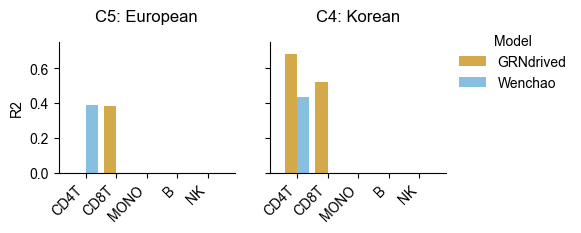

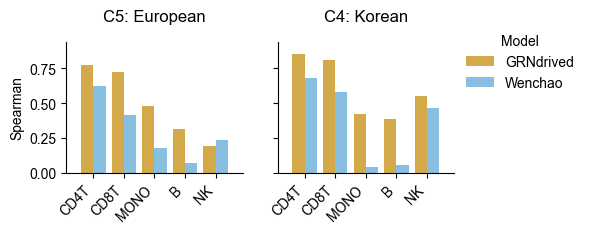

In [118]:
import matplotlib.pyplot as plt
import seaborn as sns

# Clip R2 to [0, 1]
score_df['R2'] = score_df['R2'].clip(0, 1)

# Sort datasets for consistent layout
datasets = score_df['dataset'].unique()
n_datasets = len(datasets)

# Plot each metric in a separate figure
for metric in ['R2', 'Spearman']:
    fig, axes = plt.subplots(1, n_datasets, figsize=(2.5 * n_datasets, 1.7), sharey=True)

    if n_datasets == 1:
        axes = [axes]  # Ensure iterable if only one axis

    for ax, dataset in zip(axes, datasets):
        df_plot = score_df[score_df['dataset'] == dataset]

        sns.barplot(
            data=df_plot,
            x='cell_type',
            y=metric,
            hue='model',
            ax=ax,
            alpha=0.8,
            palette=palette_models,
        )   

        ax.set_ylabel(metric)
        ax.set_xlabel('')
        ax.set_xticklabels(ax.get_xticklabels(), rotation=45, ha='right')
        ax.margins(x=0.1, y=0.1)
        ax.spines[['top', 'right']].set_visible(False)
        ax.get_legend().remove()
        ax.set_title(f'{surrogate_names[dataset]}', pad=15)

    handles, labels = axes[0].get_legend_handles_labels()
    fig.legend(handles, labels, title='Model', bbox_to_anchor=(.9, 1), loc='upper left', frameon=False)
    # fig.tight_layout()
    plt.savefig(f'{plots_dir}/clock_comparison_{metric}.png', bbox_inches='tight', dpi=300, transparent=True)


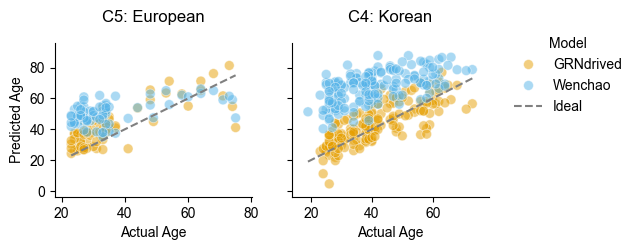

In [119]:
W_median_prediction['model'] = 'Wenchao'
test_predictions['model'] = 'GRNdrived'

obs = pd.concat([test_predictions, W_median_prediction], axis=0)
datasets = obs['dataset'].unique()

for cell_type in ['CD8T']:
    fig, axes = plt.subplots(1, len(datasets), figsize=(2.8*len(datasets), 2), sharey=True)
    i = 0
    for dataset in datasets:
        ax = axes[i] if len(datasets) > 1 else axes
        obs_d = obs[(obs['cell_type'] == cell_type) & (obs['dataset'] == dataset)].copy()

        plot_scatter_age_vs_predictedAge(obs_d, dataset=dataset, ax=ax, hue='model', palette=palette_models)
        i+=1
        ax.get_legend().remove()
    ax.legend(loc=(1.1, .5), frameon=False, title='Model')
    plt.savefig(f'{plots_dir}/clock_comparison_{cell_type}.png', bbox_inches='tight', dpi=300, transparent=True)
    
    # plt.suptitle(cell_type, fontsize=12, weight='bold')
    # plt.tight_layout()

# Performance on disease

In [120]:
obs = get_all_predictions(cell_types, ['SLE_European', 'Covid_50MHH'])

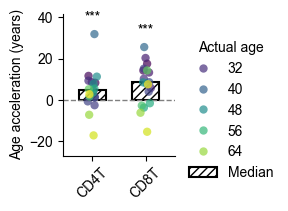

In [121]:
from ciim.src.clock.plots import wrapper_age_acceleration_disease, wrapper_age_acceleration_disease

# Call the function
wrapper_age_acceleration_disease(obs[obs['cell_type'].isin(['CD8T', 'CD4T'])], disease_dataset='SLE_European', figsize=(3, 2.5))
plt.title('')
plt.savefig(f'{plots_dir}/clock_SLE.png', bbox_inches='tight', dpi=300, transparent=True)

# wrapper_age_acceleration_disease(obs[obs['cell_type'].isin(['CD8T', 'CD4T'])], disease_dataset='Covid_50MHH')

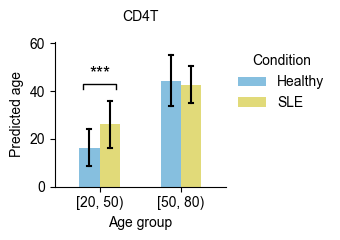

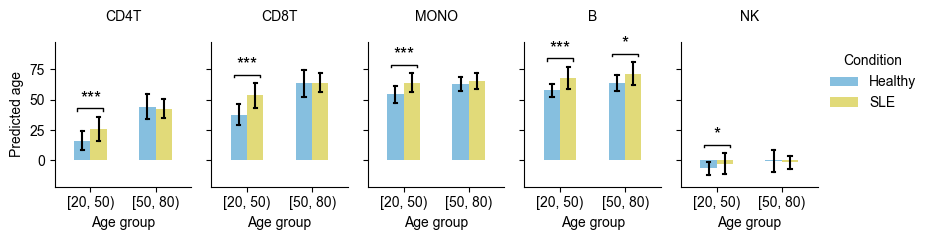

In [122]:
from ciim.src.clock.plots import wrapper_plot_age_acceleration_disease_bins
cell_type = cell_types[0]  # Example cell type, can be changed
# Example usage (make sure n_cell_types, cell_types, and surrogate_names are defined)
wrapper_plot_age_acceleration_disease_bins(obs[obs['cell_type']==cell_type], disease_dataset='SLE_European')
plt.savefig(f'{plots_dir}/clock_SLE_bins_cd8t.png', bbox_inches='tight', dpi=300, transparent=True)

aa = wrapper_plot_age_acceleration_disease_bins(obs, disease_dataset='SLE_European')
plt.savefig(f'{plots_dir}/clock_SLE_bins.png', bbox_inches='tight', dpi=300, transparent=True)
# aa = wrapper_plot_age_acceleration_disease_bins(obs, disease_dataset='Covid_50MHH')

# Perturbation

In [13]:
dataset = 'CXCL9'  #'CXCL9' # 'op' parsebioscience
target_celltypes = ['CD4T', 'CD8T'] # cell_types # ['CD4T', 'CD8T']

p_value_t = 0.05  # significance threshold
test_type='mixed_effect' 


## Extra

In [28]:
obs_pert =  get_all_predictions(cell_types, [dataset])
obs_pert = obs_pert[obs_pert['cell_type'].isin(target_celltypes)].copy()
obs_pert['test_group'] = obs_pert['donor_age'].copy()
obs_pert = obs_pert[~obs_pert['condition'].isin(['Belinostat'])]
obs_pert.head()

,sum_by,donor_age,batch_info,pool_id,age,Major_CT,donor_letter,dataset,sex,treatment_id,donor_id,cell_type,condition,cell_count,is_control,predicted_age,test_group
28,_CD4T_AG10_24 h LPS + ruxolitinib_CXCL9_TI_E,CXCL9_TI_E29,CXCL9_TI_AG10,AG10,29,CD4T,E,CXCL9,Male,8,CXCL9_TI_E,CD4T,24 h LPS + ruxolitinib,947,False,8.443430,CXCL9_TI_E29
29,_CD4T_AG11_24 h LPS + ruxolitinib_CXCL9_TI_F,CXCL9_TI_F30,CXCL9_TI_AG11,AG11,30,CD4T,F,CXCL9,Female,8,CXCL9_TI_F,CD4T,24 h LPS + ruxolitinib,965,False,6.980413,CXCL9_TI_F30
32,_CD4T_AG13_24 h LPS + ruxolitinib_CXCL9_TI_A,CXCL9_TI_A29,CXCL9_TI_AG13,AG13,29,CD4T,A,CXCL9,Male,8,CXCL9_TI_A,CD4T,24 h LPS + ruxolitinib,545,False,12.874355,CXCL9_TI_A29
35,_CD4T_AG15_24 h LPS + ruxolitinib_CXCL9_TI_B,CXCL9_TI_B28,CXCL9_TI_AG15,AG15,28,CD4T,B,CXCL9,Female,8,CXCL9_TI_B,CD4T,24 h LPS + ruxolitinib,1105,False,19.385613,CXCL9_TI_B28
36,_CD4T_AG15_24 h LPS + ruxolitinib_CXCL9_TI_G,CXCL9_TI_G26,CXCL9_TI_AG15,AG15,26,CD4T,G,CXCL9,Female,8,CXCL9_TI_G,CD4T,24 h LPS + ruxolitinib,1200,False,13.281258,CXCL9_TI_G26


In [29]:
# obs_pert['predicted_age'].hist(bins=50, density=True)

In [30]:
pretty_names = {
    '24 h LPS': 'LPS \n (ctr: RPMI)',
    # '24 h LPS + metformin': 'Met.',
    # '24 h LPS + metformin + ruxolitinib': 'LPS / Met+Rux', #Ruxolitinib
    '24 h LPS + ruxolitinib': 'Ruxolitinib \n (ctr: LPS)',
    '24 h RPMI': 'RPMI',
    # '24 h RPMI + metformin': 'RPMI+Met',
    # '24 h RPMI + metformin + ruxolitinib': 'RPMI+Met+Rux',
    '24 h RPMI + ruxolitinib': 'Ruxolitinib \n (ctr: RPMI)',
    # '24 h RPMI': 'RPMI',
    # '24 h rhCXCL9': 'rhCXCL9',
    # '24 h rhIFN-γ': 'rhIFN-γ'
}
if dataset == 'CXCL9':
    pvalue_show_type = 'raw'
    experiments = [
                    # ('24 h RPMI', '24 h rhCXCL9'),
                    # ('24 h RPMI', '24 h rhCXCL9' ),
                    ('24 h RPMI', '24 h LPS'),
                    # ('24 h RPMI', '24 h rhIFN-γ'),
                    # ('24 h RPMI', '24 h RPMI + metformin'),
                    ('24 h RPMI', '24 h RPMI + ruxolitinib'),
                    # ('24 h RPMI', '24 h RPMI + metformin + ruxolitinib'),
                    # ('24 h LPS', '24 h LPS + metformin'),
                    ('24 h LPS', '24 h LPS + ruxolitinib'),
                    # ('24 h LPS', '24 h LPS + metformin + ruxolitinib'),
                    ]
elif dataset=='op':
    pvalue_show_type = 'corrected'
    experiments = [('Dimethyl Sulfoxide', treatment) for treatment in obs_pert['condition'].unique() if treatment != 'Dimethyl Sulfoxide']
elif dataset=='parsebioscience':
    pvalue_show_type = 'corrected'
    ctr = 'PBS'
    experiments = [(ctr, treatment) for treatment in obs_pert['condition'].unique() if treatment != ctr]
else:
    raise ValueError(f"Dataset {dataset} not recognized for drug perturbation experiments.")
n_exp = len(experiments)

In [31]:
from statsmodels.stats.multitest import multipletests
import scipy.stats as stats
from ciim.src.utils.util import test_mixed_effects, test_paired, test_unpaired

# Store raw p-values and labels for later correction
raw_pvals = []
test_labels = [] 
slopes = []
pval_map = {}

for cell_type in obs_pert['cell_type'].unique():
    obs_t = obs_pert[obs_pert['cell_type'] == cell_type].copy()
    df_all = obs_t.copy()
    
    raw_pvals, slopes, test_labels = [], [], []
    
    for (ctr, treatment) in experiments:
        if (df_all['condition'] == treatment).sum() < 3:
            print(f"Skipping {cell_type} {ctr} vs {treatment} due to insufficient data.")
            continue
        
        df_sub = df_all[df_all['condition'].isin([ctr, treatment])].copy()
        if df_sub[df_sub['condition'] == treatment]['donor_age'].nunique() < 3:
            print(f"Skipping {cell_type} {ctr} vs {treatment} due to insufficient data.")
            continue

        if test_type == 'paired':
            p_value, slope = test_paired(df_sub, ctr, treatment)
        elif test_type == 'unpaired':
            p_value, slope = test_unpaired(df_sub, ctr, treatment)
        elif test_type == 'mixed_effect':
            p_value, slope = test_mixed_effects(dataset, df_sub, ctr, treatment, target_variable='predicted_age')

        if np.isnan(p_value):
            raise ValueError(f"NaN p-value for {cell_type} {ctr} vs {treatment}. Check data quality.")
        
        raw_pvals.append(p_value)
        slopes.append(slope)
        test_labels.append((cell_type, ctr, treatment))
    
    # Apply FDR correction only if we have tests for this cell type
    if raw_pvals:
        if pvalue_show_type == 'raw':
            corrected_pvals = raw_pvals
        else:
            rejected, corrected_pvals, _, _ = multipletests(raw_pvals, method='fdr_bh')       
        print(pvalue_show_type, corrected_pvals) 
        for (label, corr_pval, slope) in zip(test_labels, corrected_pvals, slopes):
            print(corr_pval)
            pval_map[label] = (corr_pval, slope)


raw [9.259630425626588e-08, 0.00679781592142329, 0.008095230757620682]
9.259630425626588e-08
0.00679781592142329
0.008095230757620682
raw [0.4295432684491042, 0.9227538210359947, 0.46360852367169936]
0.4295432684491042
0.9227538210359947
0.46360852367169936


## Sig results

[('24 h RPMI', '24 h LPS')]
number of rejuvenating drugs: 2
[]
number of rejuvenating drugs: 0


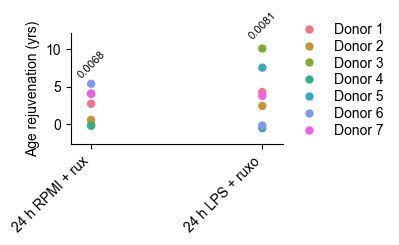

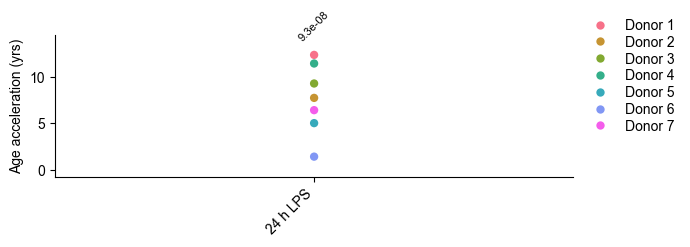

In [32]:
from ciim.src.clock.plots import plot_group_strip

def prepare_plot_inputs(cell_type):
    df_all = obs_pert[obs_pert['cell_type'] == cell_type][['test_group', 'condition', 'predicted_age']].copy()
    significant_experiments = [
        (ctr, treatment) for (ctr, treatment) in experiments
        if pval_map.get((cell_type, ctr, treatment), (1.0, 0))[0] < p_value_t
    ]
    rejuvenating = [(ctr, treatment) for (ctr, treatment) in significant_experiments 
                    if pval_map.get((cell_type, ctr, treatment), (1.0, 0))[1] < 0]
    aging = [(ctr, treatment) for (ctr, treatment) in significant_experiments 
             if pval_map.get((cell_type, ctr, treatment), (1.0, 0))[1] > 0]
    return df_all, rejuvenating, aging
for cell_type in obs_pert['cell_type'].unique():
    df_all, rejuvenating, aging = prepare_plot_inputs(cell_type)
    print(aging)
    if dataset == 'op':
        figsize=(7.5, 3)
        margins=(0.05, 0.2)
        ha = 'right'
        bbox_to_anchor=(1, 1)
    elif dataset == 'CXCL9':
        figsize=(4, 3)
        margins=(0.12, 0.2)
        ha = 'right'
        bbox_to_anchor=(1, 1.2)
    elif dataset == 'parsebioscience':
        if cell_type == 'CD4T':
            figsize=(4, 3)
            margins=(0.12, 0.2)
            ha = 'right'
            bbox_to_anchor=(1, 1.2)
        else:
            figsize=(2.5, 3)
    else:
        figsize=(7, 3)
    print('number of rejuvenating drugs:', len(rejuvenating))
    plot_group_strip(df_all, rejuvenating, "Rejuvenating", cell_type, pval_map, figsize=figsize, ha=ha, bbox_to_anchor=bbox_to_anchor, margins=margins)
    plt.title('')
    if dataset == 'op':
        plt.savefig(f'{plots_dir}/clock_{dataset}_{cell_type}_rejuvenating.png', bbox_inches='tight', dpi=300, transparent=True)
    
    
    if dataset == 'op':
        figsize=(5, 3)
        margins=(0.05, 0.2)
        ha = 'right'
        bbox_to_anchor=(1, 1)
    else:
        figsize=(7, 3)
    plot_group_strip(df_all, aging, "Acceleration", cell_type, pval_map, figsize=figsize, margins=margins, ha=ha, bbox_to_anchor=bbox_to_anchor)
    plt.title('')
    if dataset == 'op':
        plt.savefig(f'{plots_dir}/clock_{dataset}_{cell_type}_acceleration.png', bbox_inches='tight', dpi=300, transparent=True)

[('24 h LPS', '24 h LPS + ruxolitinib')]
CD4T: number of rejuvenating drugs = 1
[]
CD8T: number of rejuvenating drugs = 0


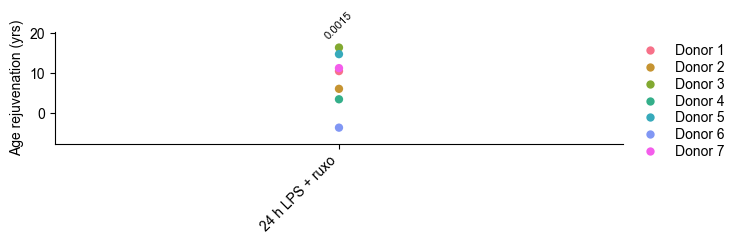

In [8]:
for cell_type in obs_pert['cell_type'].unique():
    df_all, rejuvenating, aging = prepare_plot_inputs(cell_type)

    # sort rejuvenating by p-value (ascending = most significant first)
    rejuvenating_sorted = sorted(
        rejuvenating, 
        key=lambda x: pval_map.get((cell_type, x[0], x[1]), (1.0, 0))[1]
    )
    rejuvenating_top = rejuvenating_sorted
    print(rejuvenating_top)

    # map names according to sorted order
    name_mapping = {}
    for rank, (ctr, treatment) in enumerate(rejuvenating_top, start=1):
        if rank == 1:
            name_mapping[treatment] = treatment   # most significant keeps its real name
        else:
            name_mapping[treatment] = f"Compound {rank}"  
    print(f"{cell_type}: number of rejuvenating drugs = {len(rejuvenating_top)}")
    # plot with mapped names
    plot_group_strip(
        df_all, rejuvenating_top, "Rejuvenating", cell_type, pval_map,
        figsize=(7.5, 3), ha='right', bbox_to_anchor=(1, 1),
        margins=(0.05, 0.2), name_mapping=name_mapping
    )
    plt.title('')
    if dataset == 'op':
        plt.savefig(
            f'{plots_dir}/clock_{dataset}_{cell_type}_rejuvenating_mocked.png', 
            bbox_inches='tight', dpi=300, transparent=True
        )

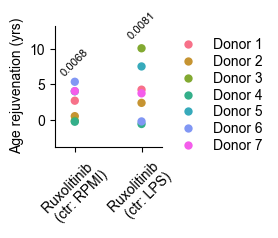

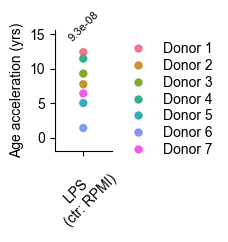

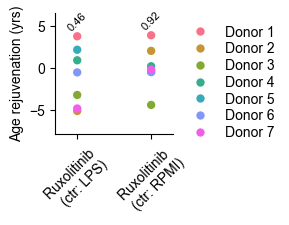

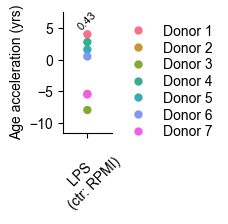

In [33]:
if True:
    from ciim.src.clock.plots import plot_experiment
    for cell_type in target_celltypes: 
        df_all = obs_pert[obs_pert['cell_type'] == cell_type]
        assert df_all.shape[0] > 0 
        if dataset == 'CXCL9':
            # plot_experiment('paired', df_all, ctr='24 h RPMI', treatment='24 h RPMI + ruxolitinib', cell_type=cell_type, pval_map=pval_map)
            # plt.legend(loc=(1.2, -.1), frameon=False)
            # plot_experiment(test_type, df_all, ctr='24 h LPS', treatment='24 h LPS + ruxolitinib', cell_type=cell_type, pval_map=pval_map)
            # plt.legend(loc=(1.2, -.1), frameon=False)
            exp = [('24 h RPMI', '24 h RPMI + ruxolitinib'), ('24 h LPS', '24 h LPS + ruxolitinib')]
            plot_group_strip(df_all, exp, "Rejuvenating", cell_type, pval_map, figsize=(3, 3), margins=(0.3, 0.3),
                            name_mapping=pretty_names, bbox_to_anchor=(1, 1), max_len=25, ha='center')
            plt.title('')
            plt.savefig(f'{plots_dir}/clock_{dataset}_{cell_type}_rejuv.png', bbox_inches='tight', dpi=300, transparent=True)

            exp = [('24 h RPMI', '24 h LPS')]
            plot_group_strip(df_all, exp, "Acceleration", cell_type, pval_map, figsize=(2.5, 3), margins=(0.3, 0.3),
                            name_mapping=pretty_names, bbox_to_anchor=(1, 1), max_len=25, ha='center')
            plt.title('')
            plt.savefig(f'{plots_dir}/clock_{dataset}_{cell_type}_acc.png', bbox_inches='tight', dpi=300, transparent=True)
        elif dataset == 'op':
            fig, axes = plt.subplots(1, 2, figsize=(4, 1.6), sharey=True)
            ax = axes[0]
            plot_experiment(test_type, df_all, ctr='Dimethyl Sulfoxide', treatment='Ruxolitinib', cell_type=cell_type, pval_map=pval_map, ax=ax)
            ax.get_legend().remove()
            ax = axes[1]            
            plot_experiment(test_type, df_all, ctr='Dimethyl Sulfoxide', treatment='LY2090314', cell_type=cell_type, pval_map=pval_map, ax=ax)
            plt.legend(loc=(1.1, .2), frameon=False)
            plt.suptitle(f'{cell_type}', y=1.1, weight='bold', fontsize=12)
        else:
            plot_experiment(test_type, df_all, ctr='PBS', treatment='IL-10', cell_type=cell_type, pval_map=pval_map)
            plt.legend(loc=(1.2, -.1), frameon=False)
            plt.suptitle(f'{cell_type}', y=1.1, weight='bold', fontsize=12)

In [10]:
aaaa

NameError: name 'aaaa' is not defined

# IBD

In [ ]:
dataset = 'ibd'
obs_pert =  get_all_predictions(cell_types, [dataset])

obs_pert['test_group'] = obs_pert['donor_age'].copy()
obs_pert.head()

,group_col,age,perturbation,sex,IL10,cell_type,condition,donor_id,disease,cell_count,dataset,is_control,donor_age,predicted_age,test_group
38,LPS_CD4T_31,52,LPS,Female,4463.78,CD4T,LPS_CD,31,CD,776,ibd,False,3152,96.605591,3152
39,LPS_CD4T_37,36,LPS,Male,2363.57,CD4T,LPS_CD,37,CD,89,ibd,False,3736,84.882681,3736
40,LPS_CD4T_43,49,LPS,Female,2848.21,CD4T,LPS_CD,43,CD,309,ibd,False,4349,90.010407,4349
41,LPS_CD4T_54,37,LPS,Male,3342.12,CD4T,LPS_CD,54,CD,814,ibd,False,5437,87.077227,5437
43,LPS_CD4T_63,61,LPS,Female,486.98,CD4T,LPS_CD,63,CD,25,ibd,False,6361,67.273839,6361


In [ ]:
# obs_pert[(obs_pert['condition']=='LPS_CD')&(obs_pert['donor_id']==obs_pert['donor_id'].unique()[4])]
# obs_pert[obs_pert['cell_type']=='CD4T'].copy()

                 Mixed Linear Model Regression Results
Model:                MixedLM     Dependent Variable:     predicted_age
No. Observations:     72          Method:                 REML         
No. Groups:           34          Scale:                  143.0850     
Min. group size:      1           Log-Likelihood:         -284.7528    
Max. group size:      3           Converged:              Yes          
Mean group size:      2.1                                              
-----------------------------------------------------------------------
                            Coef.  Std.Err.   z    P>|z|  [0.025 0.975]
-----------------------------------------------------------------------
Intercept                   27.887    3.486  8.001 0.000  21.055 34.718
disease[T.UC]                2.217    4.398  0.504 0.614  -6.403 10.837
perturbation[T.LPS]         -4.307    3.063 -1.406 0.160 -10.309  1.696
perturbation[T.S. enterica]  1.403    4.900  0.286 0.775  -8.201 11.007
Group Var

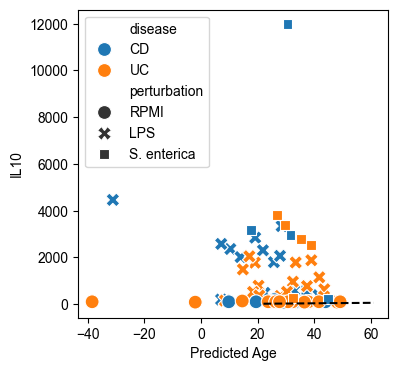

In [ ]:
import statsmodels.formula.api as smf
df = obs_pert[obs_pert['cell_type']=='CD8T'].copy()

# Ensure relevant columns are categorical
df['disease'] = df['disease'].astype('category')
df['perturbation'] = df['perturbation'].astype('category')
df['donor_id'] = df['donor_id'].astype('category')

# Set RPMI as the reference for perturbation
df['perturbation'] = df['perturbation'].cat.reorder_categories(
    ['RPMI', 'LPS', 'S. enterica'], ordered=True
)

# Mixed effects model: IL10 ~ disease + perturbation + (1|donor_id)
model = smf.mixedlm(
    "predicted_age ~ disease + perturbation",
    df,
    groups=df["donor_id"]
)
result = model.fit()
print(result.summary())

# Visualize predicted vs actual IL10
sns.scatterplot(
    data=df, x="predicted_age", y="IL10", hue="disease", style="perturbation", s=100
)
plt.plot([df.age.min(), df.age.max()], [df.age.min(), df.age.max()], 'k--')  # identity line
plt.xlabel("Predicted Age")
plt.ylabel("IL10")
plt.show()